In [41]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [ ]:
# dataset load

df = pd.read_csv(
    "../data/hour_cleaned.csv",
    parse_dates=["datetime"]
)

df = (
    df.set_index("datetime")
      .sort_index()
)

print("Shape:", df.shape)
print("Start:", df.index.min())
print("End:", df.index.max())

Shape: (17379, 17)
Start: 2011-01-01 00:00:00
End: 2012-12-31 23:00:00


In [ ]:
# restore every expected hourly timestamp so the time series remains continuous

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="h"
)

df = df.reindex(full_index)

df.index.name = "datetime"

print("Rows:", len(df))
print("Missing rows:", df["cnt"].isna().sum())

Rows: 17544
Missing rows: 165


In [ ]:
# record which observations were missing after restoring the hourly timeline

df["was_missing"] = df["cnt"].isna()

print("Missing timestamps:", df["was_missing"].sum())

Missing timestamps: 165


In [ ]:
# interpolate historical missing demand values while preserving the hourly timeline

df["target"] = (
    df["cnt"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

print("Remaining target missing:", df["target"].isna().sum())

Remaining target missing: 0


In [ ]:
# fill missing continuous and categorical features created by the restored timestamps

continuous_features = [
    "temp",
    "hum",
    "windspeed"
]

categorical_features = [
    "weathersit",
    "holiday",
    "workingday",
    "yr"
]

df[continuous_features] = (
    df[continuous_features]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

df[categorical_features] = (
    df[categorical_features]
    .ffill()
    .bfill()
)

print(df.isna().sum())

instant        165
dteday         165
season         165
yr               0
mnth           165
hr             165
holiday          0
weekday        165
workingday       0
weathersit       0
temp             0
atemp          165
hum              0
windspeed        0
casual         165
registered     165
cnt            165
was_missing      0
target           0
dtype: int64


In [ ]:
# create cyclical features representing daily and weekly time patterns

df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek

df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

In [ ]:
# select historical demand, weather, calendar, and cyclical time information

feature_columns = [
    "target",
    "temp",
    "hum",
    "windspeed",
    "weathersit",
    "holiday",
    "workingday",
    "yr",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

data = df[feature_columns].copy()

print("Number of features:", len(feature_columns))
print(feature_columns)

Number of features: 12
['target', 'temp', 'hum', 'windspeed', 'weathersit', 'holiday', 'workingday', 'yr', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


In [ ]:
# verify that the modeling dataset contains no missing or infinite values

print("NaN values:", data.isna().sum().sum())
print("Infinite values:", np.isinf(data).sum().sum())

NaN values: 0
Infinite values: 0


In [ ]:
# split the time series chronologically into training, validation, and test periods

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data.iloc[:train_end].copy()
val_data = data.iloc[train_end:val_end].copy()
test_data = data.iloc[val_end:].copy()

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)


Train: (12280, 12)
Validation: (2632, 12)
Test: (2632, 12)


In [ ]:
# fit the scaler only on training data to avoid leaking future information

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_data)

val_scaled = scaler.transform(val_data)

test_scaled = scaler.transform(test_data)

print("Train:", train_scaled.shape)
print("Validation:", val_scaled.shape)
print("Test:", test_scaled.shape)

Train: (12280, 12)
Validation: (2632, 12)
Test: (2632, 12)


In [ ]:
# Use the previous 168 hours, equivalent to seven days, to predict the next hour

WINDOW = 168

print("Window:", WINDOW, "hours")
print("Window:", WINDOW / 24, "days")

Window: 168 hours
Window: 7.0 days


In [ ]:
# Convert tabular observations into 3D sequences required by the LSTM

def create_sequences(data, window):

    X = []
    y = []

    for i in range(window, len(data)):

        X.append(
            data[i-window:i]
        )

        y.append(
            data[i, 0]
        )

    return np.array(X), np.array(y).reshape(-1, 1)

In [ ]:
# Create sequences from the training period

X_train_seq, y_train_seq = create_sequences(
    train_scaled,
    WINDOW
)

print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

X_train: (12112, 168, 12)
y_train: (12112, 1)


In [ ]:
# Include the final 168 training observations so the first validation prediction has full history

val_context = pd.concat([
    train_data.tail(WINDOW),
    val_data
])

val_context_scaled = scaler.transform(
    val_context
)

X_val_seq, y_val_seq = create_sequences(
    val_context_scaled,
    WINDOW
)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val_seq.shape)

X_val: (2632, 168, 12)
y_val: (2632, 1)


In [ ]:
# Include the final 168 validation observations so the first test prediction has full history

test_context = pd.concat([
    val_data.tail(WINDOW),
    test_data
])

test_context_scaled = scaler.transform(
    test_context
)

X_test_seq, y_test_seq = create_sequences(
    test_context_scaled,
    WINDOW
)

print("X_test:", X_test_seq.shape)
print("y_test:", y_test_seq.shape)

X_test: (2632, 168, 12)
y_test: (2632, 1)


In [ ]:
# Verify that all LSTM tensors contain valid numerical values before training

print("X_train NaN:", np.isnan(X_train_seq).sum())
print("X_val NaN:", np.isnan(X_val_seq).sum())
print("X_test NaN:", np.isnan(X_test_seq).sum())

print("y_train NaN:", np.isnan(y_train_seq).sum())
print("y_val NaN:", np.isnan(y_val_seq).sum())
print("y_test NaN:", np.isnan(y_test_seq).sum())

X_train NaN: 0
X_val NaN: 0
X_test NaN: 0
y_train NaN: 0
y_val NaN: 0
y_test NaN: 0


In [78]:
# build a two-layer LSTM model for one-hour-ahead bike demand forecasting

model = tf.keras.Sequential([
    
    tf.keras.layers.Input(
        shape=(WINDOW, len(feature_columns))
    ),

    tf.keras.layers.LSTM(
        64,
        return_sequences=True
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.LSTM(
        32
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 168, 64)        │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# stop training when validation performance stops improving and restore the best model weights

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True # keep best not worst final
)

In [80]:
# Train the LSTM using the training sequences and monitor validation performance.

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 31s 134ms/step - loss: 0.4110 - mae: 0.4523 - val_loss: 0.4944 - val_mae: 0.4732
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 23s 123ms/step - loss: 0.1641 - mae: 0.2806 - val_loss: 0.2698 - val_mae: 0.3558
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 21s 108ms/step - loss: 0.1273 - mae: 0.2481 - val_loss: 0.2062 - val_mae: 0.3139
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - loss: 0.1073 - mae: 0.2262 - val_loss: 0.2299 - val_mae: 0.3393
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - loss: 0.0964 - mae: 0.2134 - val_loss: 0.1704 - val_mae: 0.2898
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 29s 150ms/step - loss: 0.0895 - mae: 0.2068 - val_loss: 0.1538 - val_mae: 0.2738
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 29s 154ms/step - loss: 0.0857 - mae: 0.2011 - val_loss: 0.1672 - val_mae: 0.2703
Epoch 8/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 167ms/step - loss: 0.0820 - mae: 0.1964 - val_loss: 0.1431 - val_mae: 0.2601
Epoch 9/30
190/190 ━━━━━━━━━━━━━

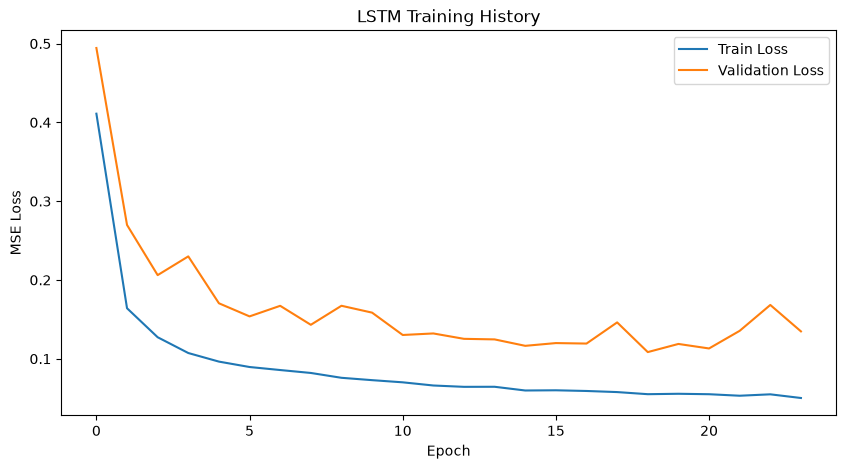

In [81]:
# Plot training and validation loss across epochs.

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training History")
plt.legend()
plt.show()

In [82]:
# Generate predictions for the unseen test period.

y_pred_scaled = model.predict(
    X_test_seq,
    verbose=0
)

print("Predictions:", y_pred_scaled.shape)

Predictions: (2632, 1)


In [83]:
# Convert scaled target values back to original bike-demand units.

target_mean = scaler.mean_[0]
target_std = scaler.scale_[0]

y_test = (
    y_test_seq.flatten() * target_std
    + target_mean
)

y_pred = (
    y_pred_scaled.flatten() * target_std
    + target_mean
)

print("Actual range:", y_test.min(), "to", y_test.max())
print("Predicted range:", y_pred.min(), "to", y_pred.max())

Actual range: 1.0 to 976.0
Predicted range: -2.3722712399156194 to 851.8365088699693


In [84]:
# Calculate test-set forecasting errors in original demand units.

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  33.51
RMSE: 51.69


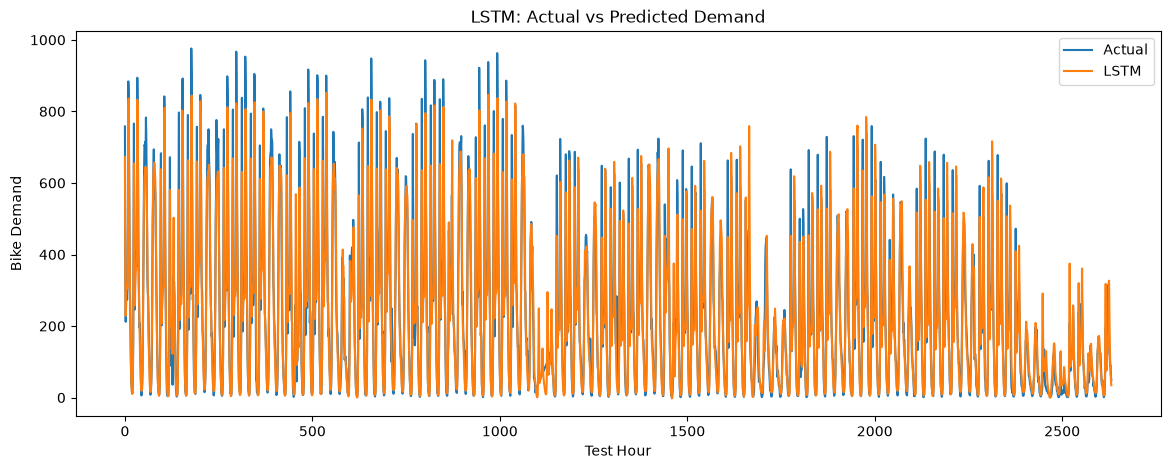

In [85]:
# Compare actual demand with LSTM predictions over the test period.

plt.figure(figsize=(14, 5))

plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="LSTM")

plt.xlabel("Test Hour")
plt.ylabel("Bike Demand")
plt.title("LSTM: Actual vs Predicted Demand")
plt.legend()

plt.show()